# Generate "clean" dataset with all normalized genes

For our final, downloadable dataset, we'll make updates to the following:

1. Include all normalized genes in the main `adata.X` object.
2. Ensure all raw data is assigned the `uint16` data type to minimize file size.
3. Update the `drawDate` field to `drawYear` for compatibility with PPI regulations.
4. Add colorsets for each cell type at each level.

We'll perform this for the main object as well as the subset objects generated for each of the major cell classes.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

from datetime import date
import hisepy
import os
import re
import scanpy as sc
import pandas as pd

In [2]:
def process_adata(adata, nn = 50, md = 0.2):

    # Keep a copy of the raw data
    adata = adata.raw.to_adata()
    adata.X = adata.X.astype('uint16')
    adata.raw = adata.copy()

    print('Normalizing', end = "; ")
    # Normalize and log transform
    sc.pp.normalize_total(adata, target_sum = 1e4)
    sc.pp.log1p(adata)

    print('Finding HVGs', end = "; ")
    # Restrict downstream steps to variable genes
    sc.pp.highly_variable_genes(adata)
    adata = adata[:, adata.var_names[adata.var['highly_variable']]].copy()

    print('Scaling', end = "; ")
    # Scale variable genes
    sc.pp.scale(adata)

    print('PCA', end = "; ")
    # Run PCA
    sc.tl.pca(adata, svd_solver = 'arpack')
    
    print('Neighbors', end = "; ")
    # Find nearest neighbors
    sc.pp.neighbors(
        adata, 
        n_neighbors = nn,
        n_pcs = 30
    )

    print('UMAP', end = "; ")
    # Run UMAP
    sc.tl.umap(adata, min_dist = md)
    
    print('Renormalizing')
    adata = adata.raw.to_adata()
    adata.raw = adata.copy()
    
    # Normalize and log transform
    sc.pp.normalize_total(adata, target_sum = 1e4)
    sc.pp.log1p(adata)
        
    return adata

In [3]:
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
    rand_str = '-'.join(rand_el)
    return rand_str

In [4]:
out_dir = 'output'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)

#### Colorsets

In [5]:
color_uuids = {
    'AIFI_L1': 'f06fcd94-834d-4490-b773-5cbb35760a51',
    'AIFI_L2': '36b6aa80-804e-4497-abe3-2d48e33bbdb5',
    'AIFI_L3': 'ee4b8ff6-3aa4-4bf0-841f-6d1b5fb284dd'
}

In [6]:
color_cache = {}
for name, uuid in color_uuids.items():
    color_cache[name] = hisepy.cache_files([uuid])[0]

In [7]:
def add_colorsets(adata, color_files):
    color_dicts = {}
    for level, file in color_files.items():
        color_df = pd.read_csv(file)
        #color_df = color_df[color_df[level].isin(adata.obs[level].unique())]

        color_dict = dict(zip(color_df[level], color_df[f'{level}_color']))
        color_dicts[level] = color_dict

    for level, color_dict in color_dicts.items():
        color_order = adata.obs[level].cat.categories
        level_colors = [color_dict[x] for x in color_order]
        adata.uns[f'{level}_colors'] = level_colors
        
    return adata

File metadata

In [8]:
sample_meta_file_uuid = '2da66a1a-17cc-498b-9129-6858cf639caf'
sample_meta_file = hisepy.cache_files([sample_meta_file_uuid])[0]
sample_meta = pd.read_csv(sample_meta_file)

In [9]:
file_meta = sample_meta[['file.id', 'sample.sampleKitGuid']]

In [10]:
file_guids = dict(zip(file_meta['sample.sampleKitGuid'],file_meta['file.id']))

## Read annotated dataset

In [11]:
h5ad_uuid = 'd316b20b-f24b-46e7-b6a1-225ca9996991'
h5ad_file = hisepy.cache_files([h5ad_uuid])[0]

In [12]:
adata = sc.read_h5ad(h5ad_file)

In [13]:
adata

AnnData object with n_obs × n_vars = 1821725 × 1236
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'file.id', 'subject.cmv', 'subject.bmi', 'celltypist.low', 'seurat.l1', 'seurat.l1.score', 'seurat.l2', 'seurat.l2.score', 'seurat.l2.5', 'seurat.l2.5.score', 'seurat.l3', 'seurat.l3.score', 'predicted_doublet', 'doublet_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', '

Convert sample.drawDate to sample.drawYear

In [14]:
adata.obs['sample.drawYear'] = [re.sub('-.+', '', d) for d in adata.obs['sample.drawDate']]
adata.obs = adata.obs.drop(['sample.drawDate', 'keep'], axis = 1)

In [15]:
adata.obs['sample.drawYear'] = adata.obs['sample.drawYear'].astype(int)

Rename pbmc_sample_id

In [16]:
adata.obs = adata.obs.rename({'pbmc_sample_id': 'specimen.specimenGuid'}, axis = 1)

Add Age Group, Age at First Draw, and Age at Draw

In [17]:
age_groups = {
    'UP1': 'Children',
    'BR1': 'Young Adult',
    'BR2': 'Older Adult'
}
adata.obs['subject.ageGroup'] = [age_groups[cohort] for cohort in adata.obs['cohort.cohortGuid']]

In [18]:
adata.obs['subject.ageAtFirstDraw'] = adata.obs['sample.drawYear'] - adata.obs['subject.birthYear']
adata.obs['sample.subjectAgeAtDraw'] = adata.obs['sample.drawYear'] - adata.obs['subject.birthYear']

Add pipeline File GUIDs

In [19]:
adata.obs['pipeline.fileGuid'] = [file_guids[k] for k in adata.obs['sample.sampleKitGuid']]

Drop unnecessary columns

In [20]:
keep_obs = [
    'cohort.cohortGuid',
    'sample.sampleKitGuid',
    'specimen.specimenGuid',
    'pipeline.fileGuid',
    'subject.subjectGuid',
    'subject.biologicalSex',
    'subject.birthYear',
    'subject.ageAtFirstDraw',
    'subject.ageGroup',
    'subject.race',
    'subject.ethnicity',
    'subject.cmv',
    'subject.bmi',
    'sample.visitName',
    'sample.drawYear',
    'sample.subjectAgeAtDraw',
    'batch_id',
    'pool_id',
    'chip_id',
    'well_id',
    'barcodes',
    'original_barcodes',
    'cell_name',
    'n_reads',
    'n_umis',
    'n_genes',
    'total_counts_mito',
    'pct_counts_mito',
    'doublet_score',
    'AIFI_L1',
    'AIFI_L2',
    'AIFI_L3'
]

In [21]:
adata.obs = adata.obs[keep_obs]

In [22]:
adata = add_colorsets(adata, color_cache)

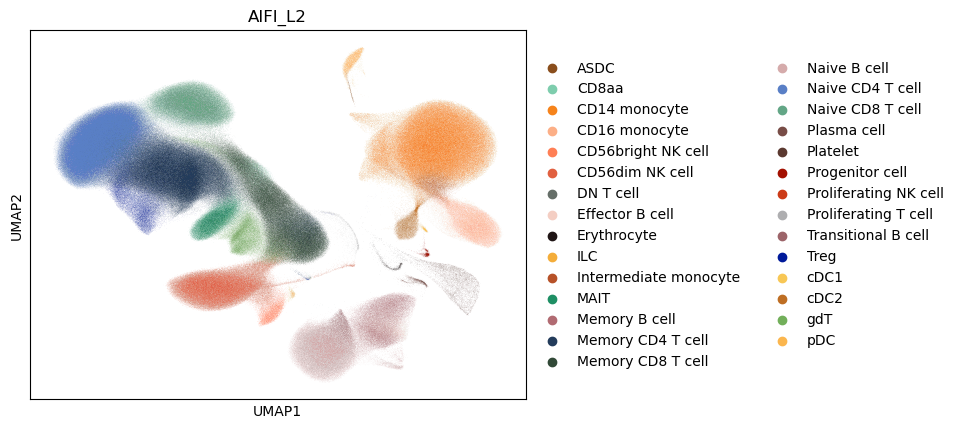

In [23]:
sc.pl.umap(adata, color = 'AIFI_L2')

### Save full dataset

In [24]:
out_files = []

In [25]:
out_file = 'output/human_immune_health_atlas_full_{d}.h5ad'.format(
    d = date.today()
)
adata.write_h5ad(out_file)
out_files.append(out_file)

### Process and output each cell class

In [26]:
l2_groups = {
    'b-plasma': ['Effector B cell', 'Memory B cell', 'Naive B cell', 'Plasma cell', 'Transitional B cell'],
    'cd4t-treg-dnt': ['DN T cell','Memory CD4 T cell', 'Naive CD4 T cell', 'Proliferating T cell', 'Treg'],
    'cd8t-gdt-mait': ['CD8aa', 'gdT', 'MAIT', 'Memory CD8 T cell', 'Naive CD8 T cell'],
    'dc': ['ASDC', 'cDC1', 'cDC2', 'pDC'],
    'mono': ['CD14 monocyte', 'CD16 monocyte', 'Intermediate monocyte'],
    'nk-ilc': ['CD56bright NK cell', 'CD56dim NK cell', 'ILC', 'Proliferating NK cell'],
    'other': ['Platelet','Erythrocyte','Progenitor cell']
}

In [27]:
for label, l2 in l2_groups.items():
    n_cells = sum(adata.obs['AIFI_L2'].isin(l2))
    print(f'{label}: {n_cells}')

b-plasma: 160632
cd4t-treg-dnt: 743615
cd8t-gdt-mait: 406730
dc: 23287
mono: 327919
nk-ilc: 148605
other: 10937


b-plasma
(160632, 33538)
uint16


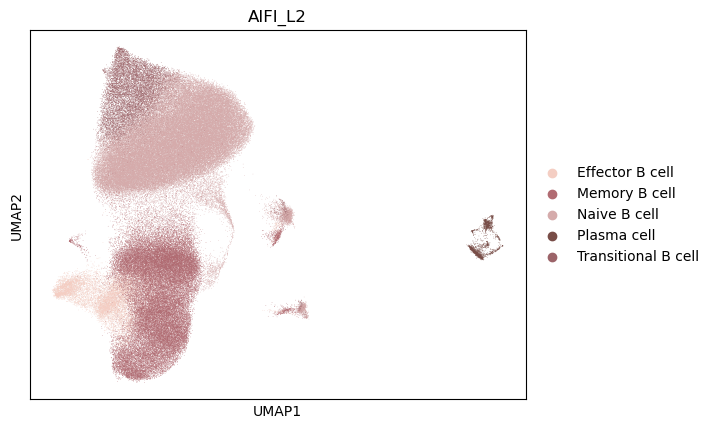

cd4t-treg-dnt
(743615, 33538)
uint16


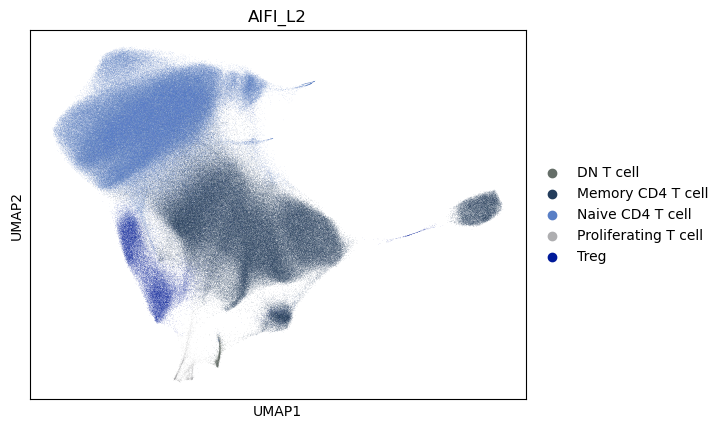

cd8t-gdt-mait
(406730, 1236)
Normalizing; WARNING: adata.X seems to be already log-transformed.
Finding HVGs; Scaling; 

/home/workspace/environment/minimal/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PCA; Neighbors; 

/home/workspace/environment/minimal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP; Renormalizing
uint16


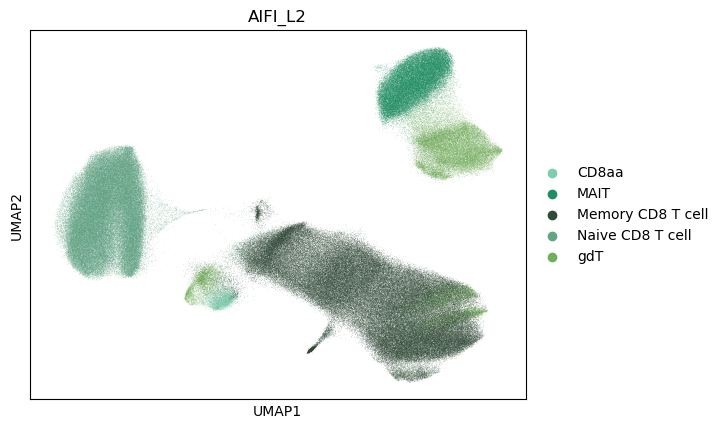

dc
(23287, 1236)
Normalizing; WARNING: adata.X seems to be already log-transformed.
Finding HVGs; Scaling; 

/home/workspace/environment/minimal/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PCA; Neighbors; UMAP; Renormalizing
uint16


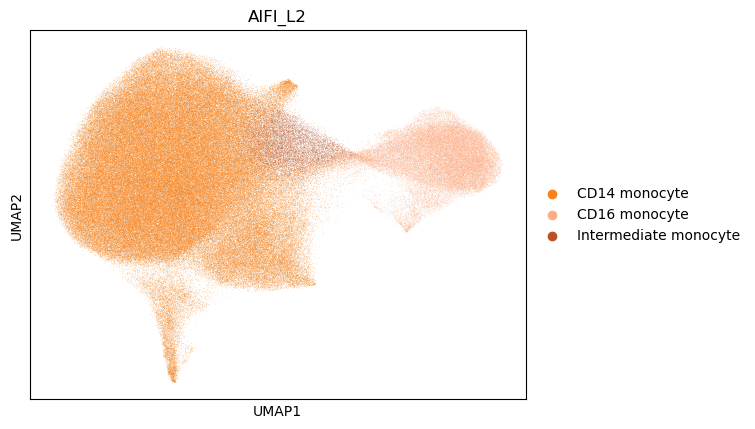

nk-ilc
(148605, 1236)
Normalizing; WARNING: adata.X seems to be already log-transformed.
Finding HVGs; Scaling; 

/home/workspace/environment/minimal/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PCA; Neighbors; UMAP; Renormalizing
uint16


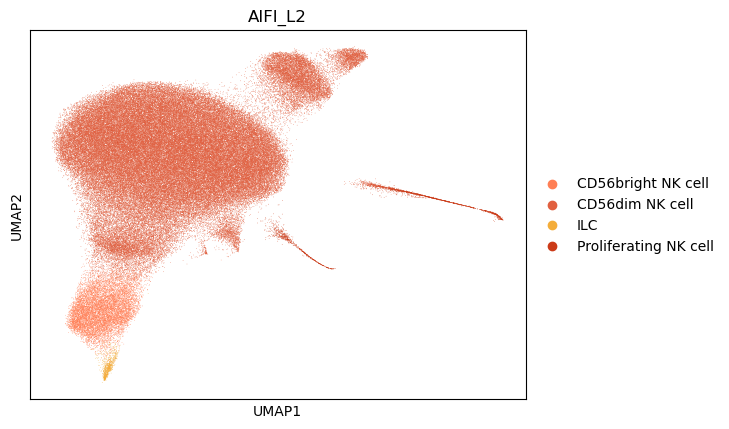

other
(10937, 1236)
Normalizing; WARNING: adata.X seems to be already log-transformed.
Finding HVGs; Scaling; 

/home/workspace/environment/minimal/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PCA; Neighbors; UMAP; Renormalizing
uint16


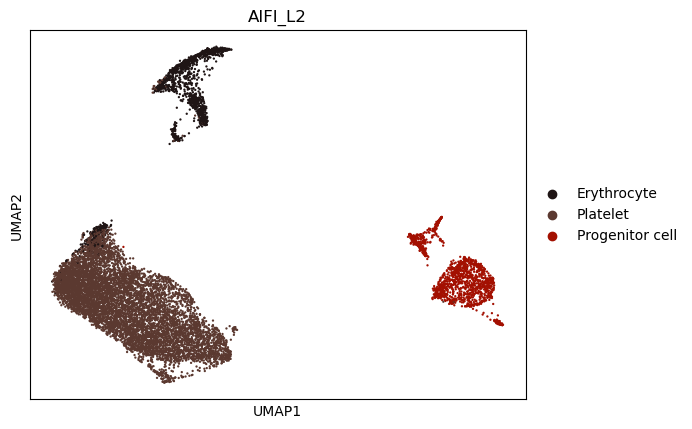

In [28]:
for cell_class, l2_labels in l2_groups.items():
    print(cell_class)
    
    out_file = 'output/human_immune_health_atlas_{c}_{d}.h5ad'.format(
        c = cell_class,
        d = date.today()
    )

    if not os.path.isfile(out_file):
        class_adata = adata[adata.obs['AIFI_L2'].isin(l2_labels)]
        print(class_adata.shape)
        
        class_adata = process_adata(class_adata)
    
        print(class_adata.raw.X.data.dtype)
    
        class_adata.write_h5ad(out_file)
    else:
        class_adata = sc.read_h5ad(out_file)
        print(class_adata.shape)
        print(class_adata.raw.X.data.dtype)
    
    sc.pl.umap(class_adata, color = 'AIFI_L2')
    del(class_adata)
    out_files.append(out_file)

## Upload results to HISE

Finally, we'll use `hisepy.upload.upload_files()` to send a copy of our output to HISE to use for downstream analysis steps.

In [29]:
study_space_uuid = '64097865-486d-43b3-8f94-74994e0a72e0'
title = 'Human Immune Health Atlas .h5ads for FileSet {d}'.format(d = date.today())

In [30]:
search_id = element_id()
search_id

'samarium-chlorine-radium'

In [31]:
in_files = [h5ad_uuid] + list(color_uuids.values()) + [sample_meta_file_uuid]

In [32]:
in_files

['d316b20b-f24b-46e7-b6a1-225ca9996991',
 'f06fcd94-834d-4490-b773-5cbb35760a51',
 '36b6aa80-804e-4497-abe3-2d48e33bbdb5',
 'ee4b8ff6-3aa4-4bf0-841f-6d1b5fb284dd',
 '2da66a1a-17cc-498b-9129-6858cf639caf']

In [33]:
out_files

['output/human_immune_health_atlas_full_2025-08-27.h5ad',
 'output/human_immune_health_atlas_b-plasma_2025-08-27.h5ad',
 'output/human_immune_health_atlas_cd4t-treg-dnt_2025-08-27.h5ad',
 'output/human_immune_health_atlas_cd8t-gdt-mait_2025-08-27.h5ad',
 'output/human_immune_health_atlas_dc_2025-08-27.h5ad',
 'output/human_immune_health_atlas_mono_2025-08-27.h5ad',
 'output/human_immune_health_atlas_nk-ilc_2025-08-27.h5ad',
 'output/human_immune_health_atlas_other_2025-08-27.h5ad']

In [34]:
hisepy.upload.upload_files(
    files = out_files,
    study_space_id = study_space_uuid,
    title = title,
    input_file_ids = in_files,
    destination = search_id
)

checking if conda environment can compile...
creating temp conda environment...
temp conda environment created successfully, now packing...
Packing environment at '/home/workspace/temp/tmp_env' to '/home/workspace/temp/conda_pack.tar.gz'

[                                        ] | 0% Completed |  0.0s
[                                        ] | 0% Completed |  0.1s
[                                        ] | 0% Completed |  0.2s
[                                        ] | 0% Completed |  0.3s
[                                        ] | 0% Completed |  0.4s
[                                        ] | 0% Completed |  0.5s
[                                        ] | 0% Completed |  0.6s
[                                        ] | 0% Completed |  0.7s
[                                        ] | 0% Completed |  0.8s
[                                        ] | 0% Completed |  0.9s
[                                        ] | 0% Completed |  1.0s
[                                  

 1


{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': 'e0c871f8-2238-4316-9d7a-c1c97c55c8ea',
 'ProcessId': '1e48bab7-564d-43b2-92ec-bd86b1e826a9',
 'WorkflowId': 'e2b77a6d-47a8-4677-ad8f-babc4768fa42',
 'FileIds': ['0cc188d1-6d07-44b9-881a-a059c21c3fa5',
  '9f76928d-a39b-45c4-8452-572a08708140',
  '35c5b09b-1eec-46cd-8d9b-1f3ea91524c8',
  '23afb869-b880-4d4c-9e79-98151bfa41e8',
  '1bc54d20-a484-4569-8e71-cd3af9489c89',
  'cb7ff965-e3a6-4269-a593-e92351d096be',
  'd5492f9b-0b19-4145-8757-13055498768b',
  'a30a5110-ba3d-46e6-abe9-94dd5e3c59f7']}

In [35]:
import session_info
session_info.show()